In [ ]:
import pandas as pd

data = pd.read_csv('netflix_titles.csv')

data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
data.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [ ]:
data = data.drop_duplicates()
data['director'] = data['director'].fillna('Unknown')
data['cast'] = data['cast'].fillna('Unknown')
data['country'] = data['country'].fillna('Unknown')
data = data.dropna(subset=['date_added'])
data['date_added'] = pd.to_datetime(data['date_added'], errors='coerce', format='mixed')
print("Data cleaned successfully!")

Data cleaned successfully!


In [ ]:
data['type'].value_counts()

,count
type,
Movie,6131
TV Show,2666


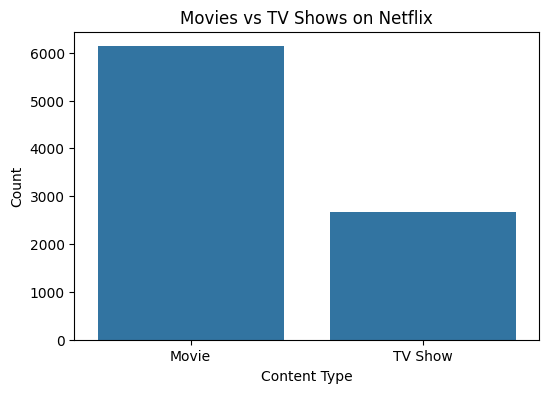

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='type', data=data)

plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Content Type')
plt.ylabel('Count')

plt.show()

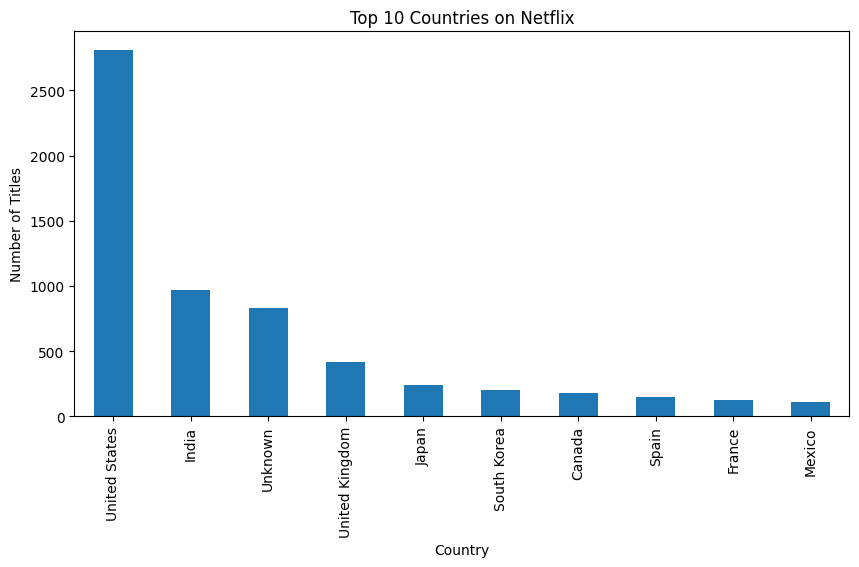

In [ ]:
top_country = data['country'].value_counts().head(10)

top_country.plot(kind='bar', figsize=(10,5))

plt.title('Top 10 Countries on Netflix')
plt.xlabel('Country')
plt.ylabel('Number of Titles')

plt.show()

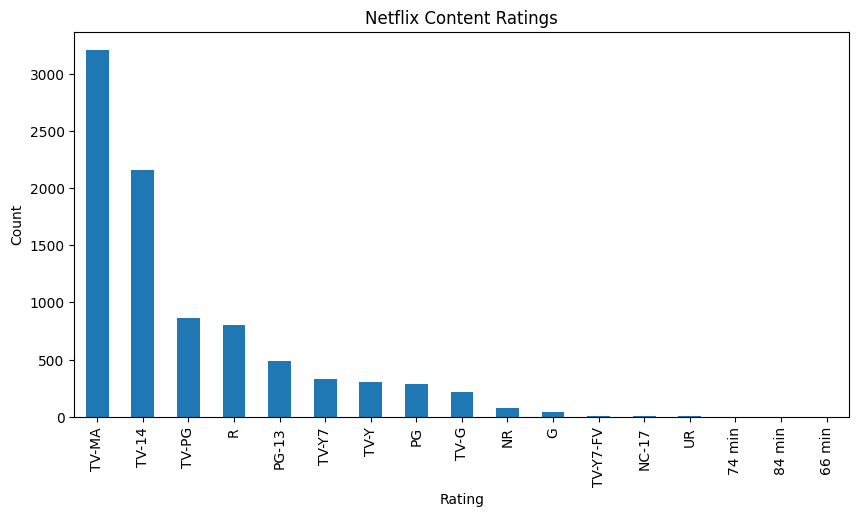

In [ ]:
ratings = data['rating'].value_counts()

plt.figure(figsize=(10,5))
ratings.plot(kind='bar')

plt.title('Netflix Content Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')

plt.show()

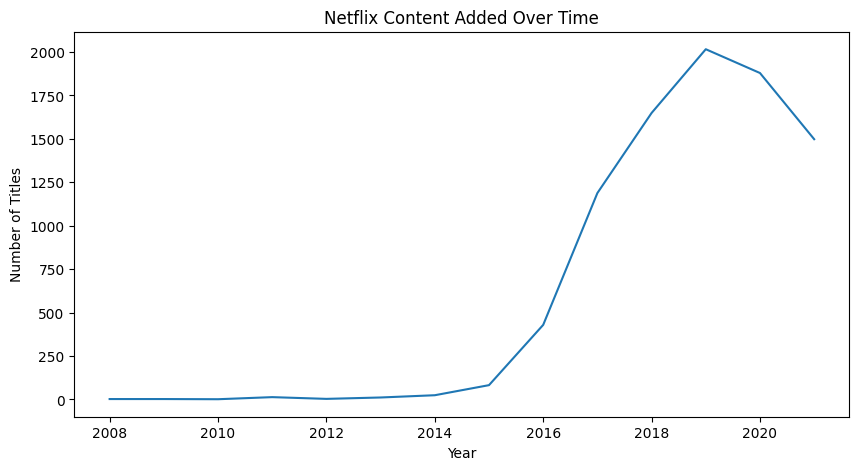

In [ ]:
data['year_added'] = data['date_added'].dt.year

yearly_content = data['year_added'].value_counts().sort_index()

yearly_content.plot(kind='line', figsize=(10,5))

plt.title('Netflix Content Added Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Titles')

plt.show()

In [ ]:
from collections import Counter

genre_counts = Counter()

data['listed_in'].dropna().apply(lambda x: genre_counts.update(x.split(', ')))

genre_df = pd.DataFrame(genre_counts.items(), columns=['Genre', 'Count'])
genre_df = genre_df.sort_values(by='Count', ascending=False)

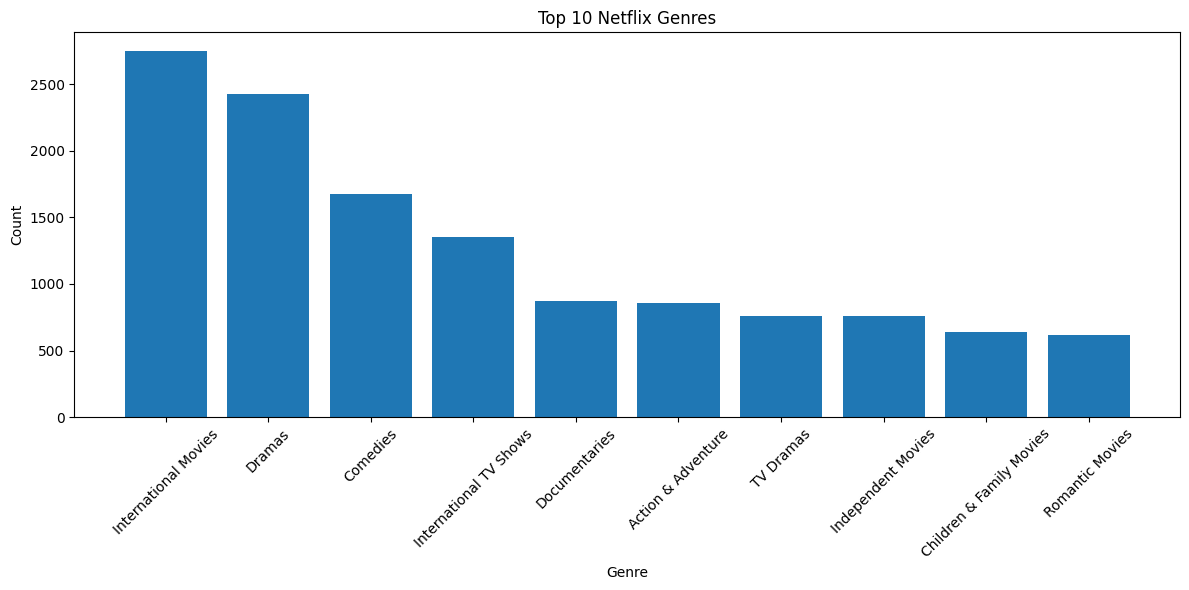

In [ ]:
top_genres = genre_df.head(10)

plt.figure(figsize=(12,6))
plt.bar(top_genres['Genre'], top_genres['Count'])

plt.title('Top 10 Netflix Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
from collections import Counter

director_counts = Counter()

data['director'].dropna().apply(lambda x: director_counts.update(x.split(', ')))

director_df = pd.DataFrame(director_counts.items(), columns=['Director', 'Count'])
director_df = director_df.sort_values(by='Count', ascending=False)


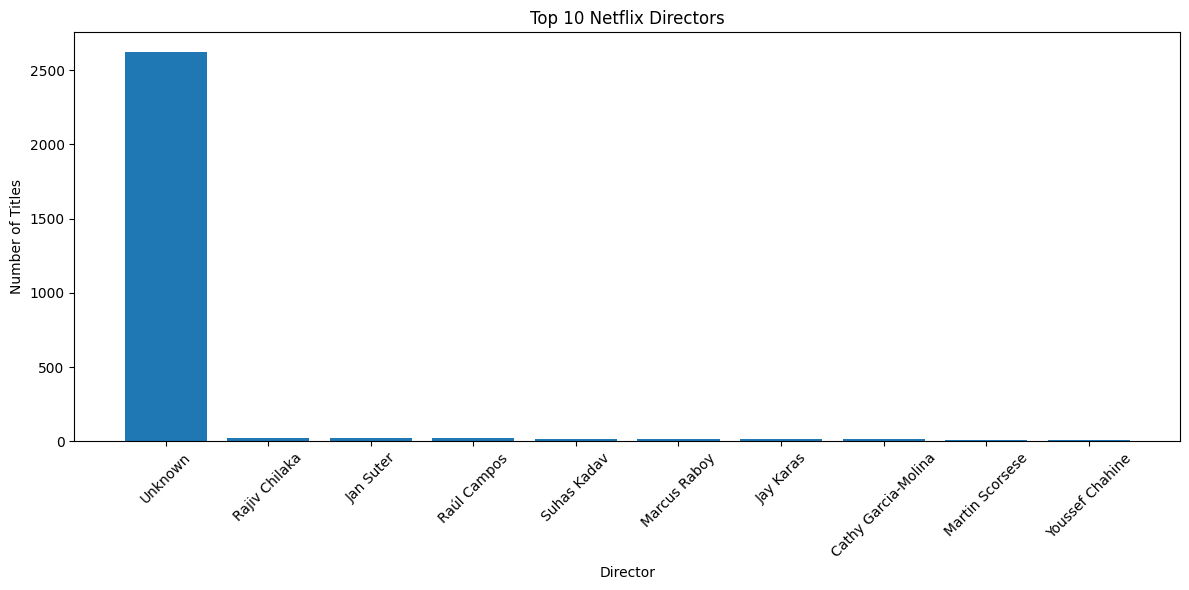

In [ ]:
top_directors = director_df.head(10)

plt.figure(figsize=(12,6))
plt.bar(top_directors['Director'], top_directors['Count'])

plt.title('Top 10 Netflix Directors')
plt.xlabel('Director')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
data[['duration']].head()

,duration
0,90 min
1,2 Seasons
2,1 Season
3,1 Season
4,2 Seasons


In [ ]:
movies = data[data['type'] == 'Movie']
tv_shows = data[data['type'] == 'TV Show']

In [ ]:
movies = data[data['type'] == 'Movie'].copy()

movies['duration_int'] = movies['duration'].str.replace(' min', '').astype(float)

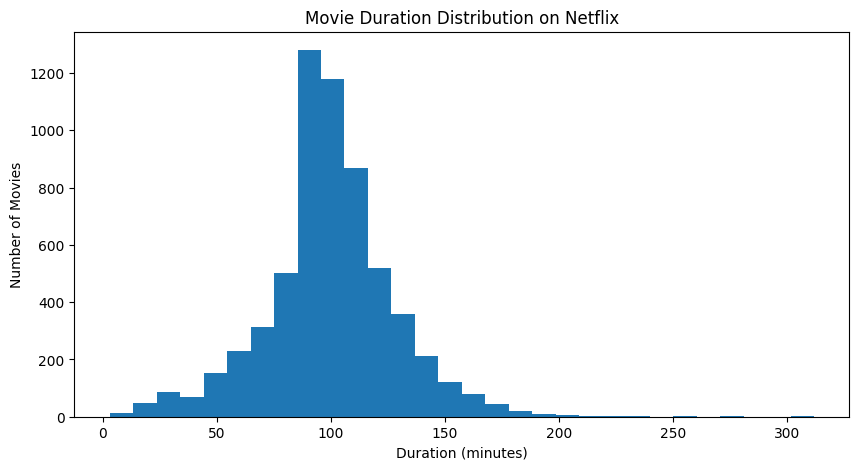

In [ ]:
plt.figure(figsize=(10,5))
plt.hist(movies['duration_int'], bins=30)

plt.title('Movie Duration Distribution on Netflix')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')

plt.show()

In [ ]:
tv_shows = data[data['type'] == 'TV Show'].copy()

In [ ]:
tv_shows['seasons'] = tv_shows['duration'].str.replace(' Seasons', '').str.replace(' Season', '').astype(float)

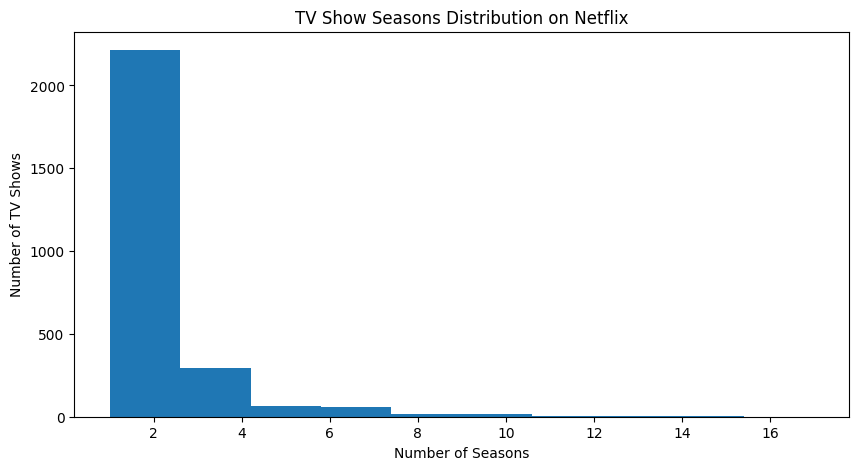

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(tv_shows['seasons'], bins=10)

plt.title('TV Show Seasons Distribution on Netflix')
plt.xlabel('Number of Seasons')
plt.ylabel('Number of TV Shows')

plt.show()

In [ ]:
data.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,4
duration,3
